# Backprop with a neuron function

## with a mathematical model of a nueron we are trying to learn back propogration

In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt

#this line of code will show the graphs inside of the notebook, its jp notebook specific:-
%matplotlib inline 

## Value class
- the reason we are implementing this class is basically to keep a track of what operations led us to the result 
- simply said , we are traking the previoud nodes of the tree , and the tree itself is the arithmatic equation 
- we are also storing the gradient of the loss function, with respect to each node 
- the main benifit of using this data structre is that we can back propogate through the computation graph, to find out how each node influences the loss function 

In [27]:
class Value:
    
    def __init__(self, data, _children=(), _op='' , label=''):
         self.data = data
         self.prev = set(_children)
         self.op = _op
         self.label = label
         self.grad = 0.0
    def __repr__(self):
         return f"Value(data={self.data})"
    
    def __add__(self, other):
         return Value(self.data + other.data, (self,other), '+')  
    def __mul__(self, other):
         return Value(self.data * other.data, (self,other), '*') 
    def tanh(self):
         x=self.data
         t=(math.exp(2*x) -1)/(math.exp(2*x)+1)
         output = Value(t, (self, ), 'tanh')
         return output

In [28]:
from graphviz import Digraph

def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # value node (rounded box)
        dot.node(uid, label=f"{{ {n.label} | data: {n.data:.4f} | grad: {n.grad:.4f} }}", shape='record')
        # if this value was produced by an op, create an op node
        if n.op:
            op_uid = uid + n.op
            dot.node(op_uid, label=n.op)
            dot.edge(op_uid, uid)

    for n1, n2 in edges:
        # connect n1 to n2's op node
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot

In [ ]:

# inputs are x and y
x=Value(2.0, label = 'x')
y=Value(0.0, label='y')

#weights w1, w2
w1=Value(-3.0, label = 'w1')
w2=Value(1.0, label = 'w2')

#bias of the neuron
b = Value(8, label = 'b')

#the neuron funtion:-
xw1=x*w1 ; xw1.label='x.w1'
yw2=y*w2 ; yw2.label='y.w2'

sum = xw1 + yw2 ; sum.label = 'summation'

neuron = sum + b; neuron.label ='neuron'

output = neuron.tanh() ; output.label = 'output'

draw_dot(output)

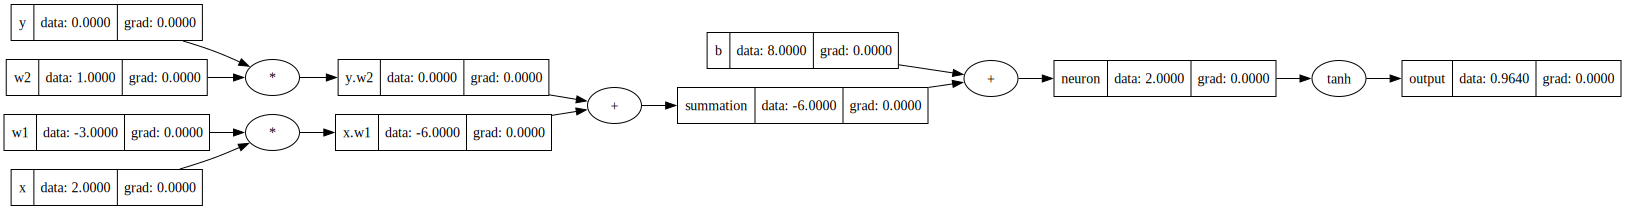